<h1 style="text-align: center;">SMT Challenge 2025 Catch Probability Model</h1>
<h3 style="text-align: center;"><i>Team 15</i> - this notebook is used to develop our version of the catch probability model</h3>

### Necessary Libraries

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
baby_red_blue_cmap = LinearSegmentedColormap.from_list("baby_red_blue", ["#89CFF0", "#ffffff", "#CC3433"])
import seaborn as sns
from scipy.stats import norm, gamma
from scipy.optimize import minimize_scalar
from pygam import LogisticGAM, s, f
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.metrics import confusion_matrix, roc_auc_score, log_loss, f1_score

## set up the random seed to generate same results
np.random.seed(42)

pd.set_option('display.max_columns', None)

### Helper Functions

In [10]:
def info_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    Displays information about the dataframe with # of missing values, unique numbers, datatypes, etc.
    
    Arguments: Dataframe
    """
    df = df.copy()
    dtype = df.dtypes
    num_unique = df.T.apply(lambda x: x.nunique(), axis=1)
    nan_total = df.isnull().sum()
    nan_percent = (df.isnull().sum()/df.isnull().count()*100)
    quality_df = pd.concat([nan_total, nan_percent, num_unique, dtype], axis=1, keys=['total_NaNs', 'NaN%', 'num_unique', 'dtypes'])
    display(quality_df)

In [11]:
def catch_made_hist(df: pd.DataFrame, column: str, ax=None) -> None:
    """
    Displays overlapping histograms between successful catches and not for some column
    
    Arguments: column: is some quantitative column in df
    """
    df = df.copy()

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
        
    ax.hist(df[df['is_out_catch'] == 0][column], bins=25, alpha=0.7, label='Made catch == 0', color='#CC3433', density=True)
    ax.hist(df[df['is_out_catch'] == 1][column], bins=25, alpha=0.7, label='Made catch == 1', color='#89CFF0', density=True)
    ax.set_xlabel(column.replace('_', ' '))
    ax.set_ylabel('Density')
    ax.set_title(f"{column.replace('_', ' ')} Histograms\n Comparisons")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

In [12]:
def bootstrap_uniform(data: np.array, n=10_000) -> tuple:
    """
    Uses the bootstrap method to find the 95% CI estimate for alpha and beta of the Uniform distribution

    Arguments: observed_data: a column's values, n: number of iterations
    """
    sample_size = len(data)
    alpha_values = []
    beta_values = []

    ## bootstrap resampling -> finding n randomly estimated alpha's and beta's and putting them into respective lists
    for _ in range(n):
        bootstrap_sample = np.random.choice(data, size=sample_size, replace=True)
        ## sampled alpha & beta
        alpha_hat = np.min(bootstrap_sample)
        alpha_values.append(alpha_hat)
        
        beta_hat = np.max(bootstrap_sample)
        beta_values.append(beta_hat)
    
    ## computing the 95% CI for the estimated alpha and beta
    ## the lower limit alpha value and upper limit alpha value
    alpha_values.sort()
    alpha_lower_limit = alpha_values[int(0.025 * n)]
    alpha_upper_limit = alpha_values[int(0.975 * n)]
    ## the lower limit beta value and upper limit beta value
    beta_values.sort()
    beta_lower_limit = beta_values[int(0.025 * n)]
    beta_upper_limit = beta_values[int(0.975 * n)]

    return np.mean([alpha_lower_limit, alpha_upper_limit]), np.mean([beta_lower_limit, beta_upper_limit])

In [14]:
def catch_prob_cm(y_test: np.array, y_pred: np.array) -> None:
    """
    Plots the confusion matrix of y_test vs y_pred
    
    Arguments: y_test: the test labels, y_pred: the predicted test labels
    """
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=baby_red_blue_cmap, xticklabels=['Pred No Catch', 'Pred Catch'], yticklabels=['No Catch', 'Catch'])
    plt.xlabel('Predicted')
    plt.ylabel('Observed')
    plt.title('Catch Probability Confusion Matrix')
    plt.show()

In [15]:
def partial_dependence_plots(model, features: list) -> None:
    """
    Visualizes the partial dependencies of each feature
    The code is mostly taken from pyGAM's documentation: https://pygam.readthedocs.io/en/latest/notebooks/tour_of_pygam.html
    
    Arguments: model: fitted GAM model, features: list of features (must match order of columns in training data)
    """
    fig, axs = plt.subplots(1, len(features), figsize=(5 * len(features), 4))

    for i, ax in enumerate(axs):
        XX = model.generate_X_grid(term=i)
        pdep, confi = model.partial_dependence(term=i, width=.95)
        ax.plot(XX[:, i], pdep)
        ax.plot(XX[:, i], confi, c='r', ls='--')
        ax.set_title(features[i])
        ax.set_xlabel(features[i])
        ax.set_ylabel("Log-Odds")
    plt.tight_layout()
    plt.show()

In [16]:
def assign_difficulty(prob: float):
    """
    Assigns the difficulty level of the catch probability based on Savant's levels

    Arguments: prob: the catch prob value
    """
    difficulty_levels_dict = {'1 Star': (90, 100), 
                              '2 Star': (75, 90), 
                              '3 Star': (50, 75), 
                              '4 Star': (25, 50), 
                              '5 Star': (0, 25)}
    
    ## loops through the difficulty levels to find the appropriate level
    for star, (min_p, max_p) in difficulty_levels_dict.items():
        if min_p < prob*100 <= max_p:
            return star
        ## handles the catch prob with 0%
        elif prob*100 == 0:
            return '5 Star'

### Catch Probability EDA

In [107]:
catch_prob_df = pd.read_csv('play_data.csv').iloc[:, 1:].copy()

In [108]:
info_table(catch_prob_df)

,total_NaNs,NaN%,num_unique,dtypes
game_str_id,0,0.000000,5312,object
distance_traveled_7,0,0.000000,5310,float64
distance_traveled_8,0,0.000000,5312,float64
distance_traveled_9,0,0.000000,5310,float64
opportunity_time,0,0.000000,291,float64
hang_time,0,0.000000,1068,float64
direction_angle_7,0,0.000000,6,object
direction_angle_8,0,0.000000,6,object
direction_angle_9,0,0.000000,6,object
distance_needed_7,0,0.000000,5312,float64


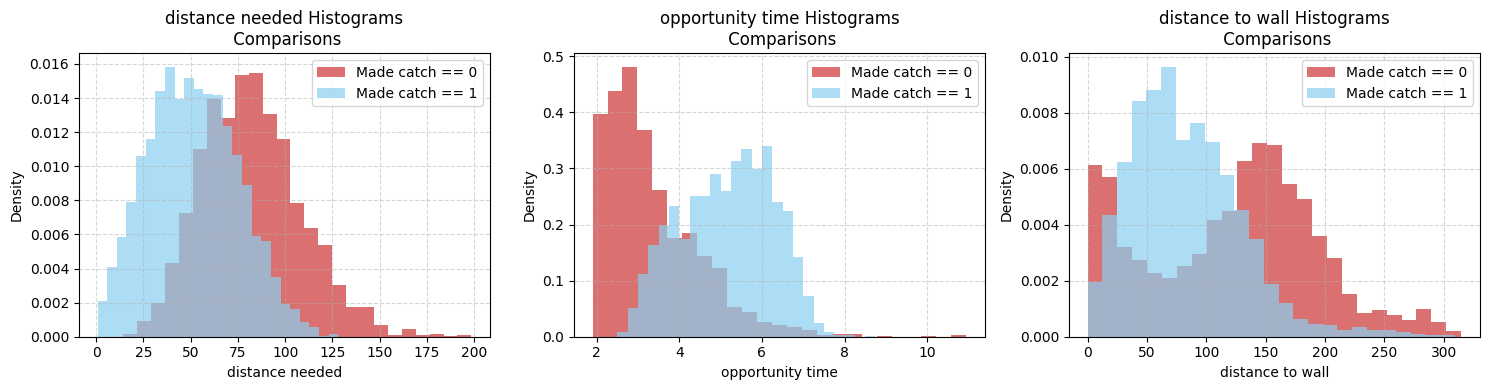

In [109]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
catch_made_hist(catch_prob_df, 'distance_needed', ax=ax1)
catch_made_hist(catch_prob_df, 'opportunity_time', ax=ax2)
catch_made_hist(catch_prob_df, 'distance_to_wall', ax=ax3)
plt.tight_layout()
plt.show()

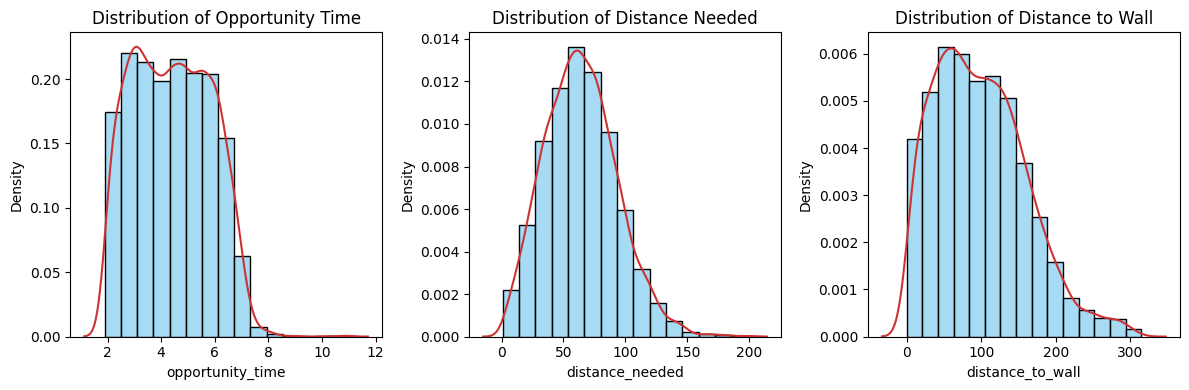

In [110]:
## Plots of our models's features' histograms
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
sns.histplot(data=catch_prob_df, x='opportunity_time', stat='density', bins=15, color='#89CFF0', ax=ax1)
sns.kdeplot(data=catch_prob_df, x='opportunity_time', color='#CC3433', ax=ax1)
ax1.set_title('Distribution of Opportunity Time')

sns.histplot(data=catch_prob_df, x='distance_needed', stat='density', bins=15, color='#89CFF0', ax=ax2)
sns.kdeplot(data=catch_prob_df, x='distance_needed', color='#CC3433', ax=ax2)
ax2.set_title('Distribution of Distance Needed')

sns.histplot(data=catch_prob_df, x='distance_to_wall', stat='density', bins=15, color='#89CFF0', ax=ax3)
sns.kdeplot(data=catch_prob_df, x='distance_to_wall', color='#CC3433', ax=ax3)
ax3.set_title('Distribution of Distance to Wall')

plt.tight_layout()
plt.show()

The observed distribution of opportunity time seems roughly Uniform from 2 to around 7 -> use bootstrapping to find the estimated alpha and beta
* Opportunity Time ~ Unif($\alpha \approx$ 2, $\beta\approx$ 7)

The observed distribution of distance needed seems roughly Normal as its shape replicates a bell curve with a heavy-ish right-tail -> use MLE to find $\hat\mu$ and $\hat\sigma^2$
* Distance Needed ~ N($\hat\mu$, $\hat\sigma^2$)

The observed distribution of distance to wall looks roughly like a Gamma distribution, given the skewed right nature and all positive values
* Distance to Wall ~ Gamma($\hat\alpha, \hat\beta$)

In [111]:
## filters opportunity_time to be within (2.5%, 97.5%) of the data -> im using the central 95% because of the observed outliers in opportunity_time
lower_ot_95, upper_ot_95 = np.percentile(catch_prob_df['opportunity_time'], [2.5, 97.5])
opportunity_time_95 = catch_prob_df['opportunity_time'][(catch_prob_df['opportunity_time'] >= lower_ot_95) & (catch_prob_df['opportunity_time'] <= upper_ot_95)].values
## computes the estimated alpha and beta of opportunity_time ~ Unif(alpha, beta) where alpha and beta are the sample min and max after filtering
unif_distrib = np.random.uniform(low=np.min(opportunity_time_95), high=np.max(opportunity_time_95), size=len(opportunity_time_95))
opportunity_time_alpha, opportunity_time_beta = bootstrap_uniform(unif_distrib)
opportunity_time_alpha, opportunity_time_beta

(2.100572815136692, 6.896664684766612)

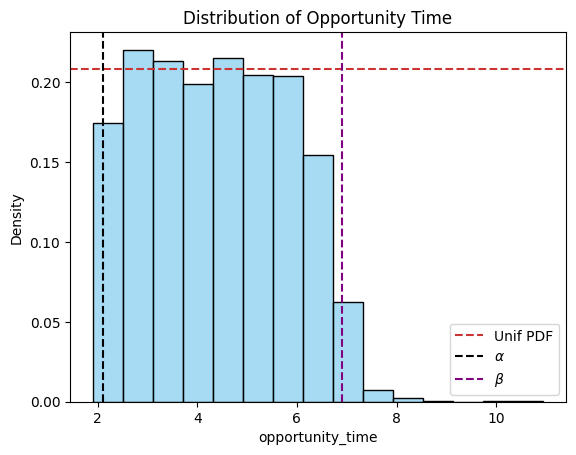

In [112]:
## plotting the unif pdf onto Opportunity Time
plt.figure()
unif_pdf = 1 / (np.max(opportunity_time_95) - np.min(opportunity_time_95))
plt.axhline(y=unif_pdf, color='#CC3433', linestyle='--', label='Unif PDF')
plt.axvline(x=np.min(opportunity_time_95), color='black', linestyle='--', label=r'$\alpha$')
plt.axvline(x=np.max(opportunity_time_95), color='purple', linestyle='--', label=r'$\beta$')
sns.histplot(data=catch_prob_df, x='opportunity_time', stat='density', bins=15, color='#89CFF0')
plt.title('Distribution of Opportunity Time')
plt.legend()
plt.show()

In [113]:
## computes the sample mean, std, and var -> these are the MLE estimates for the Normal distrib
x_bar = np.mean(catch_prob_df['distance_needed'])
s_sq_hat = np.var(catch_prob_df['distance_needed'])
s_hat = s_sq_hat ** (1/2)
x_bar, s_hat, s_sq_hat

(64.21096528927843, 29.000585021472798, 841.0339315876723)

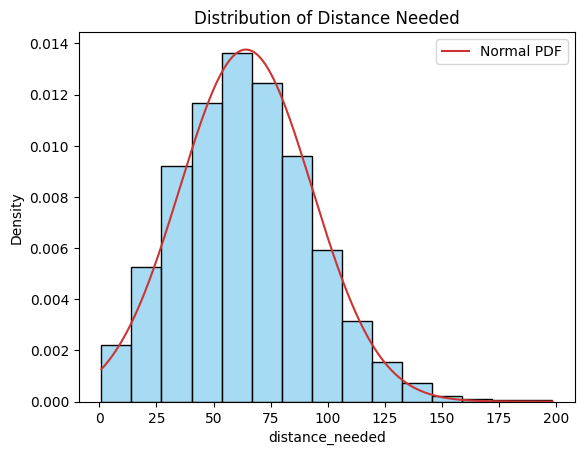

In [114]:
## Plots of our models's features' histograms
plt.figure()
sns.histplot(data=catch_prob_df, x='distance_needed', stat='density', bins=15, color='#89CFF0')
x_values = np.linspace(catch_prob_df['distance_needed'].min(), catch_prob_df['distance_needed'].max(), len(catch_prob_df['distance_needed']))
normal_pdf = (1 / (s_hat * np.sqrt(2*np.pi))) * np.exp((-(x_values-x_bar)**2) / (2 * s_sq_hat))
plt.plot(x_values, normal_pdf, color='#CC3433', label='Normal PDF')
# sns.kdeplot(data=catch_prob_df, x='distance_needed', color='#CC3433', ax=ax2)
plt.title('Distribution of Distance Needed')
plt.legend()
plt.show()

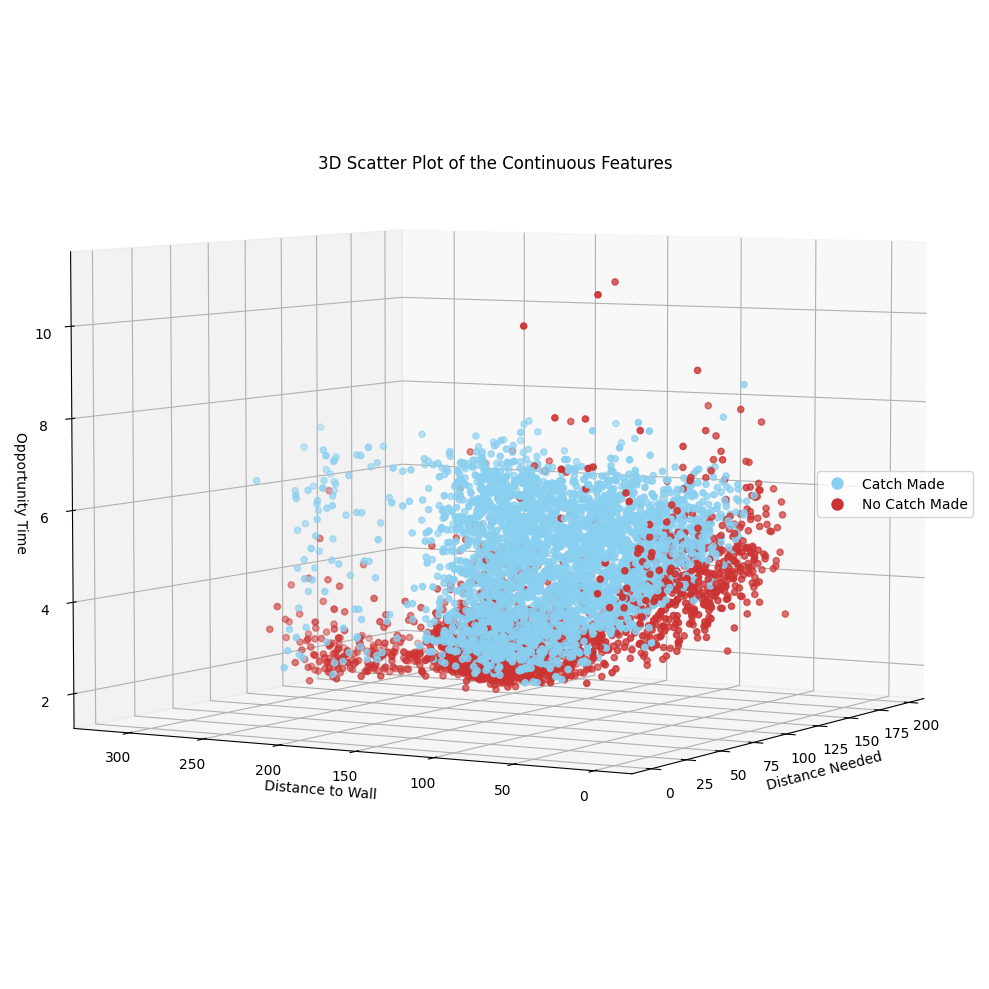

In [256]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D

colors = catch_prob_df['is_out_catch'].map({0: '#CC3433', 1: '#89CFF0'})

legend_elements = [Line2D([0], [0], marker='o', color='w', label='Catch Made', markerfacecolor='#89CFF0', markersize=10), 
                   Line2D([0], [0], marker='o', color='w', label='No Catch Made', markerfacecolor='#CC3433', markersize=10)
                   ]


fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
ax.scatter(catch_prob_df['distance_needed'], catch_prob_df['distance_to_wall'], catch_prob_df['opportunity_time'], c=colors, marker='o')
ax.set_xlabel('Distance Needed')
ax.set_ylabel('Distance to Wall')
ax.set_zlabel('Opportunity Time', labelpad=0)
ax.set_title('3D Scatter Plot of the Continuous Features', y=0.9)
ax.view_init(elev=5, azim=210)
ax.legend(handles=legend_elements, loc='center right')
plt.tight_layout()
plt.show()

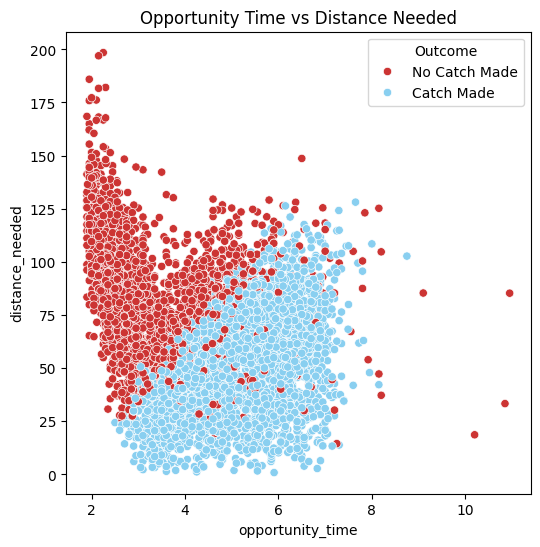

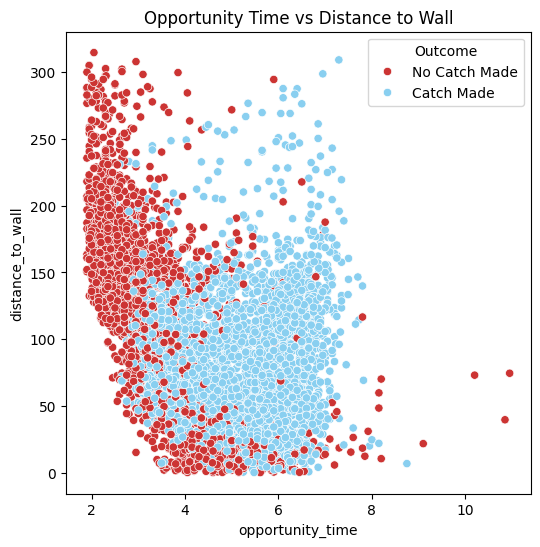

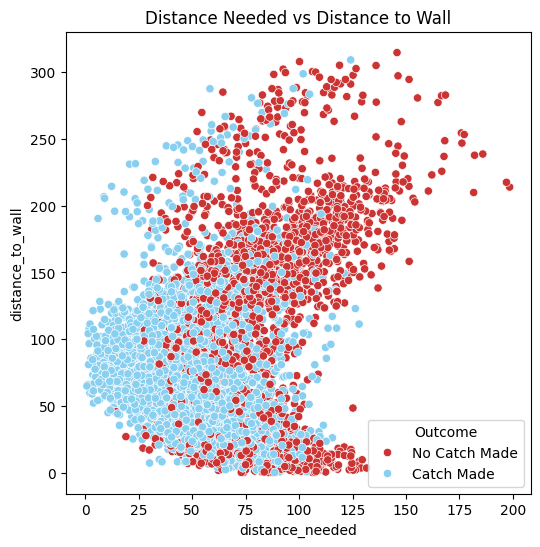

In [223]:
plt.figure(figsize=(6, 6))
scatter_plot = sns.scatterplot(data=catch_prob_df, x='opportunity_time', y='distance_needed', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
handles, labels = scatter_plot.get_legend_handles_labels()
scatter_plot.legend(handles=handles, labels=['No Catch Made', 'Catch Made'], title='Outcome')
plt.title('Opportunity Time vs Distance Needed')
plt.show()

plt.figure(figsize=(6, 6))
scatter_plot = sns.scatterplot(data=catch_prob_df, x='opportunity_time', y='distance_to_wall', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
handles, labels = scatter_plot.get_legend_handles_labels()
scatter_plot.legend(handles=handles, labels=['No Catch Made', 'Catch Made'], title='Outcome')
plt.title('Opportunity Time vs Distance to Wall')
plt.show()

plt.figure(figsize=(6, 6))
scatter_plot = sns.scatterplot(data=catch_prob_df, x='distance_needed', y='distance_to_wall', hue='is_out_catch', palette={0: '#CC3433', 1: '#89CFF0'})
handles, labels = scatter_plot.get_legend_handles_labels()
scatter_plot.legend(handles=handles, labels=['No Catch Made', 'Catch Made'], title='Outcome')
plt.title('Distance Needed vs Distance to Wall')
plt.show()

### Catch Probability Baseline GAM

In [161]:
## baseline model with only opportunity time + distance needed
X = catch_prob_df[['opportunity_time', 'distance_needed']].copy()
y = catch_prob_df['is_out_catch'].values
X = scaler.fit_transform(X[['opportunity_time', 'distance_needed']])

## finds the optimized lambda using the train-test-split -> not the cv b/c it'd be too slow to find the best params
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state = 42)
grid_gam = LogisticGAM(s(0) + s(1)).gridsearch(X_train, y_train, lam=np.logspace(-3, 3, 10))
print(grid_gam.lam)

f1_score_baseline_scores = []
log_loss_baseline_scores = []

best_baseline_log_loss = np.inf
best_baseline_f1_score = np.inf
best_baseline_gam = None

## validates the model using 10-fold validation with 5 repetitions
baseline_cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)
for train_idx, test_idx in baseline_cv.split(X, y):
    X_train_baseline_cv, X_test_baseline_cv = X[train_idx], X[test_idx]
    y_train_baseline_cv, y_test_baseline_cv = y[train_idx], y[test_idx]

    baseline_gam = LogisticGAM(s(0, lam=2.154434690031882) + s(1, lam=2.154434690031882)).fit(X_train_baseline_cv, y_train_baseline_cv)
    
    y_pred_proba_baseline_cv = baseline_gam.predict_proba(X_test_baseline_cv)
    y_pred_baseline_cv = baseline_gam.predict(X_test_baseline_cv)
    f1 = f1_score(y_test_baseline_cv, y_pred_baseline_cv)
    log_losses = log_loss(y_test_baseline_cv, y_pred_proba_baseline_cv)
    f1_score_baseline_scores.append(roc_auc)
    log_loss_baseline_scores.append(log_losses)

    ## best gam is the one with the lowest log_loss
    if log_losses < best_baseline_log_loss:
        best_baseline_log_loss = log_losses
        best_baseline_f1_score = f1
        best_y_baseline = y_test_baseline_cv
        best_y_pred_baseline = y_pred_baseline_cv
        best_baseline_gam = baseline_gam

best_baseline_gam.summary()

  0% (0 of 10) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:133: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:134: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: overflow en

did not converge


/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:133: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:134: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: overflow encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
 30% (3 of 

[[2.154434690031882], [2.154434690031882]]
LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     12.6308
Link Function:                        LogitLink Log Likelihood:                                 -1122.9182
Number of Samples:                         4781 AIC:                                              2271.098
                                                AICc:                                            2271.1816
                                                UBRE:                                               2.4771
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0

/var/folders/6l/fh4ck8px62x4x7vp3j9kjr6h0000gn/T/ipykernel_33250/2844112776.py:41: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  best_baseline_gam.summary()


#### Results

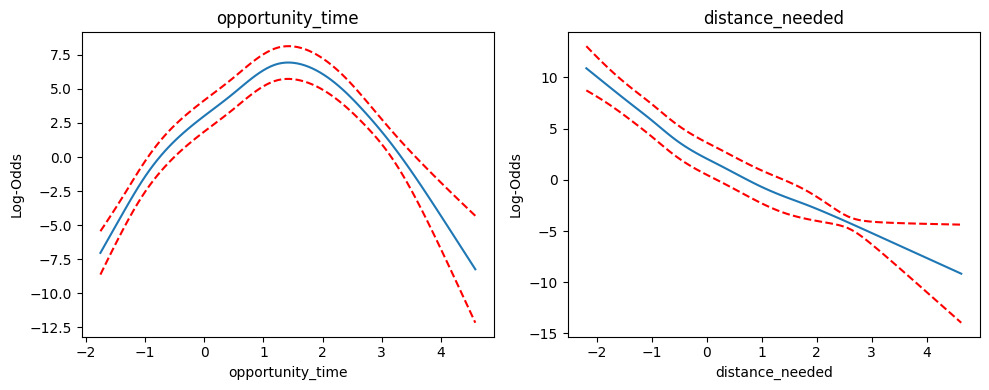

In [162]:
partial_dependence_plots(best_baseline_gam, ['opportunity_time', 'distance_needed'])

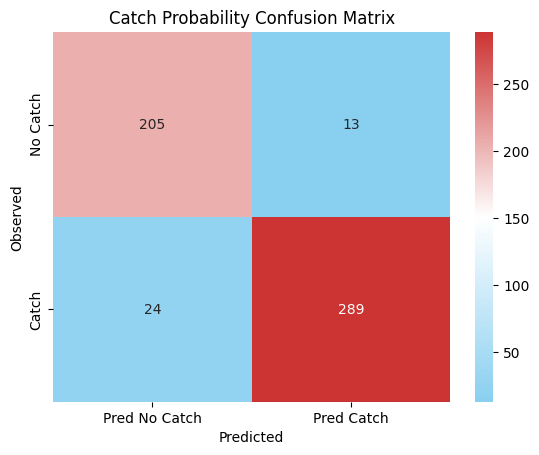

,best_log_loss,avg_log_loss,log_loss_std,f1
baseline_gam,0.182029,0.232338,0.025504,0.939837


In [163]:
## test set results
catch_prob_cm(best_y_baseline, best_y_pred_baseline)

test_baseline_dict = {}
test_baseline_dict['best_log_loss'] = best_log_loss
test_baseline_dict['avg_log_loss'] = np.mean(log_loss_baseline_scores)
test_baseline_dict['log_loss_std'] = np.std(log_loss_baseline_scores)
test_baseline_dict['f1'] = best_baseline_f1_score
test_baseline_df = pd.DataFrame([test_baseline_dict], index=['baseline_gam'])

test_baseline_df

### Catch Probability Improved? GAM

In [164]:
## model with opportunity time + distance needed + now direction angle
## turning direction_angle into a categorical feature
X2 = catch_prob_df[['opportunity_time', 'distance_needed', 'direction_angle']].copy()
X2.loc[:, 'direction_cat_code'] = X2['direction_angle'].astype('category').cat.codes
direction_categories = X2['direction_angle'].astype('category').cat.categories
X2_scaled = scaler.fit_transform(X2[['opportunity_time', 'distance_needed']].values)
X2 = np.hstack([X2_scaled, X2[['direction_cat_code']].values])
y2 = catch_prob_df['is_out_catch'].values

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, stratify=y2, random_state=42)
grid_gam_w_direction = LogisticGAM(s(0) + s(1) + f(2)).gridsearch(X2_train, y2_train, lam=np.logspace(-3, 3, 10))
print(grid_gam_w_direction.lam)

f1_score_model2_scores = []
log_loss_model2_scores = []

best_log_loss2 = np.inf
best_f1_score2 = np.inf
best_gam_w_direction = None

## validates the model using 10-fold validation with 5 repetitions
model_2_cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)
for train_idx, test_idx in model_2_cv.split(X2, y2):
    X2_train_cv, X2_test_cv = X2[train_idx], X2[test_idx]
    y2_train_cv, y2_test_cv = y2[train_idx], y2[test_idx]

    gam_w_direction = LogisticGAM(s(0, lam=10) + s(1, lam=10) + f(2, lam=10)).fit(X2_train_cv, y2_train_cv)
    
    y2_pred_proba_cv = gam_w_direction.predict_proba(X2_test_cv)
    y2_pred_cv = gam_w_direction.predict(X2_test_cv)
    f1 = f1_score(y2_test_cv, y2_pred_cv)
    log_losses = log_loss(y2_test_cv, y2_pred_proba_cv)
    f1_score_model2_scores.append(roc_auc)
    log_loss_model2_scores.append(log_losses)

    ## best gam is the one with the lowest log_loss
    if log_losses < best_log_loss2:
        best_log_loss2 = log_losses
        best_f1_score2 = f1
        best_test_y2= y2_test_cv
        best_test_y2_pred = y2_pred_cv
        best_gam_w_direction = gam_w_direction

best_gam_w_direction.summary()

  0% (0 of 10) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:133: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:134: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: overflow encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/butt

did not converge


/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/utils.py:799: RuntimeWarning: divide by zero encountered in divide
  out[mask] = y[mask] * np.log(y[mask] / u[mask])
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/utils.py:799: RuntimeWarning: overflow encountered in divide
  out[mask] = y[mask] * np.log(y[mask] / u[mask])
 20% (2 of 10) |#####                    | Elapsed Time: 0:00:10 ETA:   0:00:40
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:133: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:134: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: overflow e

did not converge


...

/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/utils.py:799: RuntimeWarning: divide by zero encountered in divide
  out[mask] = y[mask] * np.log(y[mask] / u[mask])
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/utils.py:799: RuntimeWarning: overflow encountered in divide
  out[mask] = y[mask] * np.log(y[mask] / u[mask])
 40% (4 of 10) |##########               | Elapsed Time: 0:00:12 ETA:   0:00:18
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:133: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:134: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: overflow e

did not converge


 50% (5 of 10) |############             | Elapsed Time: 0:00:12 ETA:   0:00:12
 60% (6 of 10) |###############          | Elapsed Time: 0:00:12 ETA:   0:00:08
 70% (7 of 10) |#################        | Elapsed Time: 0:00:12 ETA:   0:00:05
 80% (8 of 10) |####################     | Elapsed Time: 0:00:13 ETA:   0:00:03
 90% (9 of 10) |######################   | Elapsed Time: 0:00:14 ETA:   0:00:01
100% (10 of 10) |########################| Elapsed Time: 0:00:14 Time:  0:00:14


[[10.0], [10.0], [10.0]]
LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     13.6045
Link Function:                        LogitLink Log Likelihood:                                 -1087.7308
Number of Samples:                         4781 AIC:                                             2202.6707
                                                AICc:                                            2202.7663
                                                UBRE:                                                2.463
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.6638
Feature Func

/var/folders/6l/fh4ck8px62x4x7vp3j9kjr6h0000gn/T/ipykernel_33250/804813756.py:44: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  best_gam_w_direction.summary()


#### Results

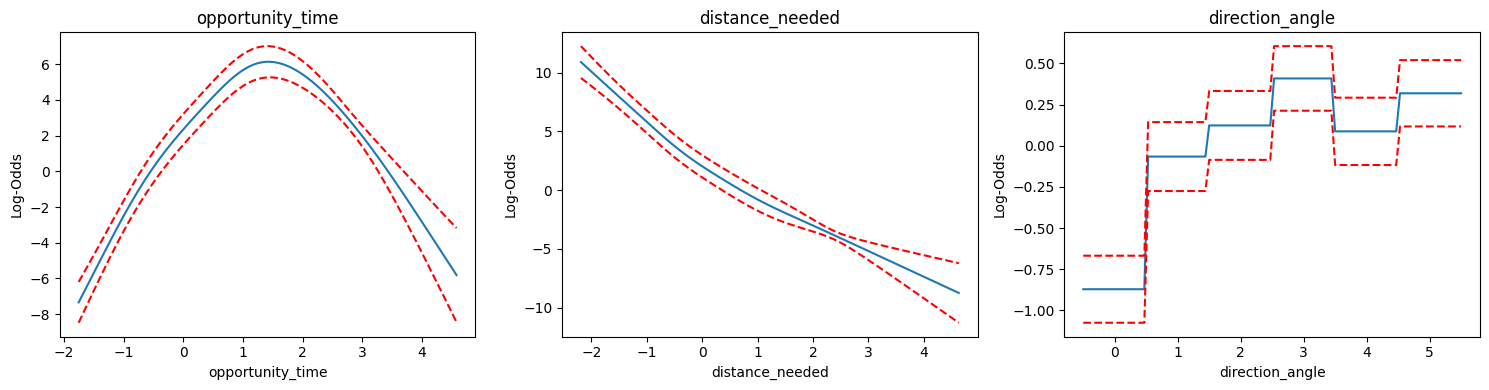

In [165]:
partial_dependence_plots(best_gam_w_direction, ['opportunity_time', 'distance_needed', 'direction_angle'])

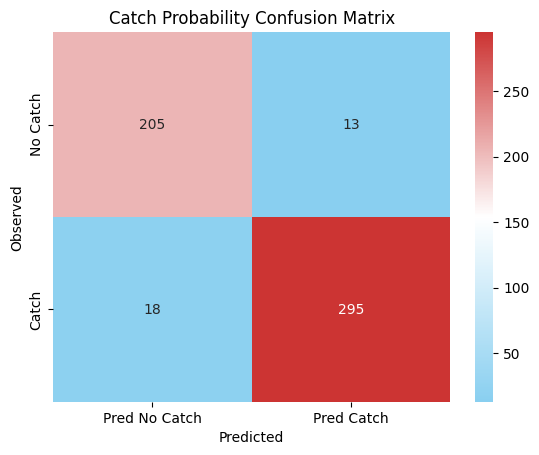

,best_log_loss,avg_log_loss,log_loss_std,f1
gam_w_direction,0.17798,0.225194,0.024619,0.950081


In [166]:
## test set results
catch_prob_cm(best_test_y2, best_test_y2_pred)

test_model2_dict = {}
test_model2_dict['best_log_loss'] = best_log_loss2
test_model2_dict['avg_log_loss'] = np.mean(log_loss_model2_scores)
test_model2_dict['log_loss_std'] = np.std(log_loss_model2_scores)
test_model2_dict['f1'] = best_f1_score2
test_model2_df = pd.DataFrame([test_model2_dict], index=['gam_w_direction'])
test_model2_df

### Catch Probability Improved?? GAM

In [173]:
direction_categories

Index(['Back', 'Back Left', 'Back Right', 'In', 'In Left', 'In Right'], dtype='object')

In [167]:
## model with opportunity time + distance needed + direction angle + now distance to wall
## turning direction_angle into a categorical feature
X3 = catch_prob_df[['opportunity_time', 'distance_needed', 'distance_to_wall', 'direction_angle']].copy()
X3.loc[:, 'direction_cat_code'] = X3['direction_angle'].astype('category').cat.codes
direction_categories = X3['direction_angle'].astype('category').cat.categories
X3_scaled = scaler.fit_transform(X3[['opportunity_time', 'distance_needed', 'distance_to_wall']].values)
X3 = np.hstack([X3_scaled, X3[['direction_cat_code']].values])
y3 = catch_prob_df['is_out_catch'].values

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.25, stratify=y3, random_state=42)
grid_gam_w_wall = LogisticGAM(s(0) + s(1) + s(2) + f(3)).gridsearch(X3_train, y3_train, lam=np.logspace(-3, 3, 10))
print(grid_gam_w_wall.lam)

f1_score_model3_scores = []
log_loss_model3_scores = []

best_log_loss3 = np.inf
best_f1_score3 = np.inf
best_gam_w_wall = None

## validates the model using 10-fold validation with 5 repetitions
model_3_cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)
for train_idx, test_idx in model_3_cv.split(X3, y3):
    X3_train_cv, X3_test_cv = X3[train_idx], X3[test_idx]
    y3_train_cv, y3_test_cv = y3[train_idx], y3[test_idx]

    gam_w_wall = LogisticGAM(s(0, lam=10) + s(1, lam=10) + s(2, lam=10) + f(3, lam=10)).fit(X3_train_cv, y3_train_cv)
    
    y3_pred_proba_cv = gam_w_wall.predict_proba(X3_test_cv)
    y3_pred_cv = gam_w_wall.predict(X3_test_cv)
    f1 = f1_score(y3_test_cv, y3_pred_cv)
    log_losses = log_loss(y3_test_cv, y3_pred_proba_cv)
    f1_score_model3_scores.append(f1)
    log_loss_model3_scores.append(log_losses)

    ## best gam is the one with the lowest log_loss
    if log_losses < best_log_loss3:
        best_log_loss3 = log_losses
        best_f1_score3 = f1
        best_test_y3 = y3_test_cv
        best_test_y3_pred = y3_pred_cv
        best_gam_w_wall = gam_w_wall

best_gam_w_wall.summary()

  0% (0 of 10) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:133: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:134: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: overflow en

did not converge


/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/utils.py:799: RuntimeWarning: divide by zero encountered in divide
  out[mask] = y[mask] * np.log(y[mask] / u[mask])
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/utils.py:799: RuntimeWarning: overflow encountered in divide
  out[mask] = y[mask] * np.log(y[mask] / u[mask])
 20% (2 of 10) |#####                    | Elapsed Time: 0:00:23 ETA:   0:01:32
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:133: RuntimeWarning: overflow encountered in exp
  elp = np.exp(lp)


did not converge


/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:134: RuntimeWarning: invalid value encountered in divide
  return dist.levels * elp / (elp + 1)
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/links.py:149: RuntimeWarning: overflow encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: overflow encountered in square
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/pygam.py:627: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2
/Users/buttz/miniforge3/lib/python3.10/site-packages/pygam/utils.py:799: RuntimeWarning: divide by zero encountered in divide
  out[mask] = y[mask]

did not converge


 40% (4 of 10) |##########               | Elapsed Time: 0:00:27 ETA:   0:00:41
 50% (5 of 10) |############             | Elapsed Time: 0:00:28 ETA:   0:00:28
 60% (6 of 10) |###############          | Elapsed Time: 0:00:28 ETA:   0:00:19
 70% (7 of 10) |#################        | Elapsed Time: 0:00:29 ETA:   0:00:12
 80% (8 of 10) |####################     | Elapsed Time: 0:00:29 ETA:   0:00:07
 90% (9 of 10) |######################   | Elapsed Time: 0:00:32 ETA:   0:00:03
100% (10 of 10) |########################| Elapsed Time: 0:00:33 Time:  0:00:33


[[10.0], [10.0], [10.0], [10.0]]
LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                     18.5543
Link Function:                        LogitLink Log Likelihood:                                  -994.0744
Number of Samples:                         4781 AIC:                                             2025.2574
                                                AICc:                                            2025.4263
                                                UBRE:                                               2.4267
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.6927
Feat

/var/folders/6l/fh4ck8px62x4x7vp3j9kjr6h0000gn/T/ipykernel_33250/1618963748.py:44: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  best_gam_w_wall.summary()


#### Results

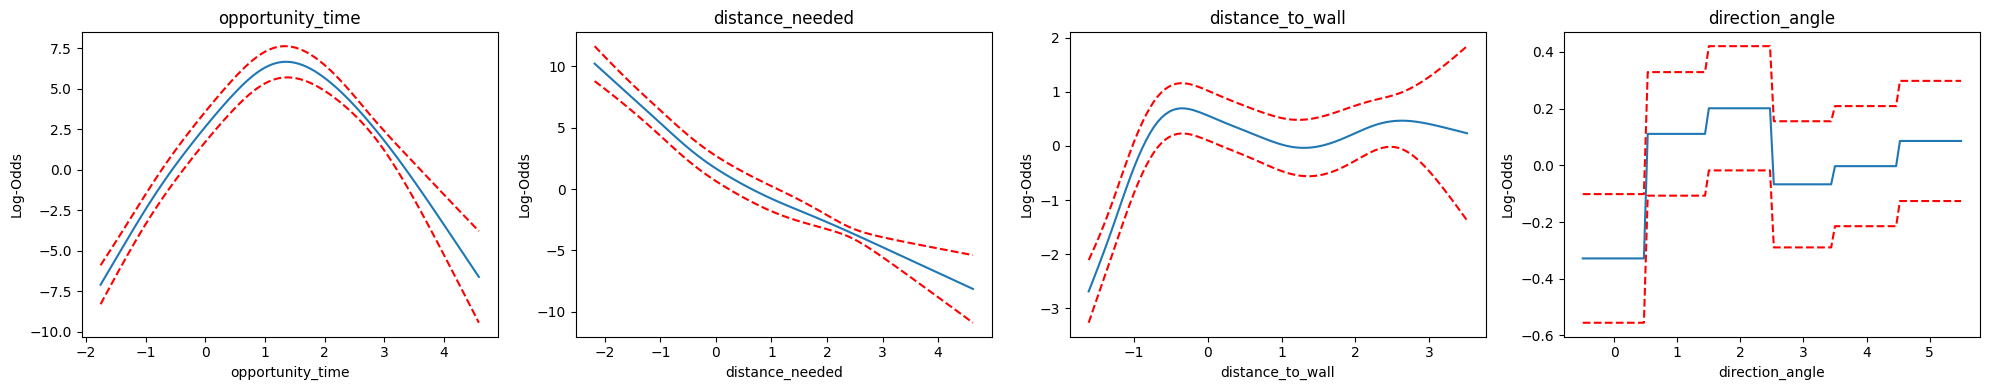

In [168]:
partial_dependence_plots(best_gam_w_wall, ['opportunity_time', 'distance_needed', 'distance_to_wall', 'direction_angle'])

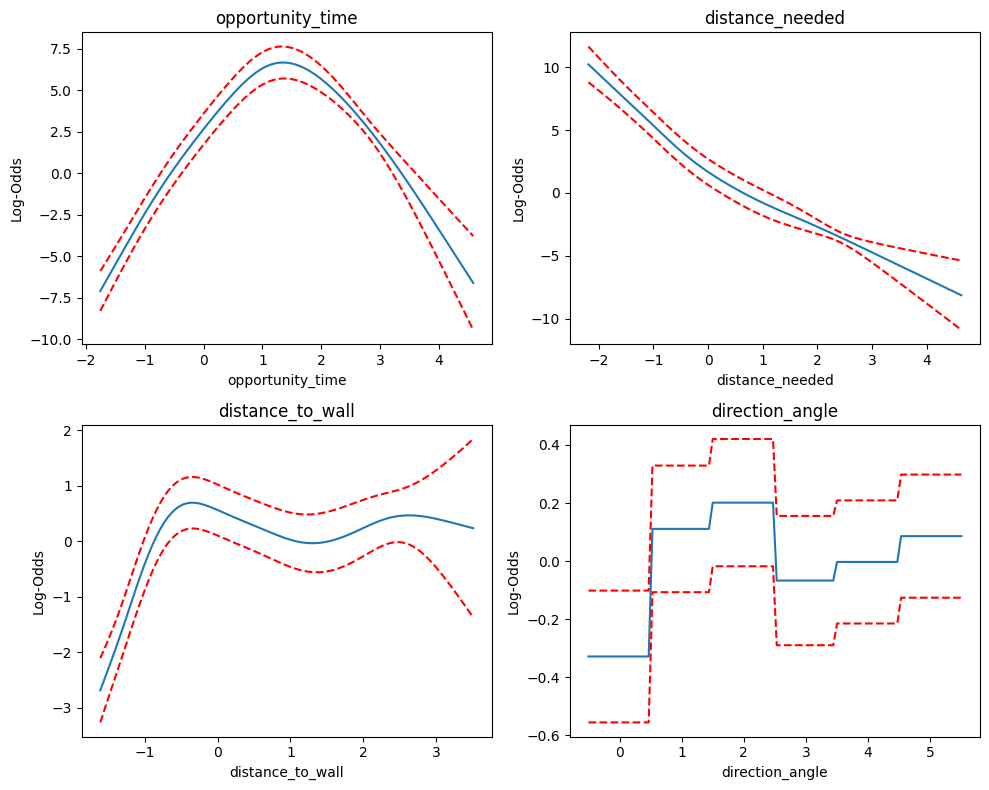

In [258]:
## turns the above partial dependence plots into 2x2 (for the paper)
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()

for i, ax in enumerate(axs):
    XX = best_gam_w_wall.generate_X_grid(term=i)
    pdep, confi = best_gam_w_wall.partial_dependence(term=i, width=.95)
    ax.plot(XX[:, i], pdep)
    ax.plot(XX[:, i], confi, c='r', ls='--')
    ax.set_title(['opportunity_time', 'distance_needed', 'distance_to_wall', 'direction_angle'][i])
    ax.set_xlabel(['opportunity_time', 'distance_needed', 'distance_to_wall', 'direction_angle'][i])
    ax.set_ylabel("Log-Odds")

plt.tight_layout()
plt.show()

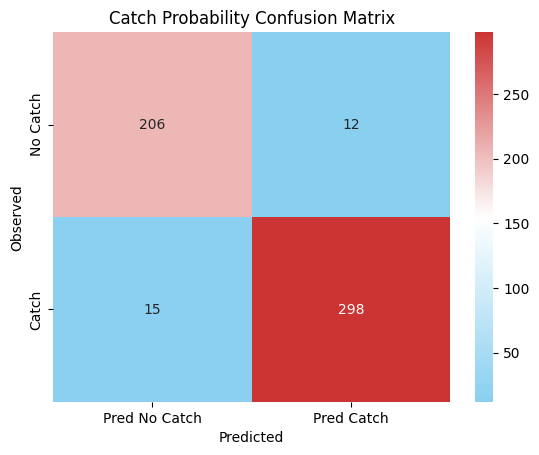

,best_log_loss,avg_log_loss,log_loss_std,f1
gam_w_wall,0.1624,0.206978,0.022409,0.956661


In [170]:
## test set results
catch_prob_cm(best_test_y3, best_test_y3_pred)

test_model3_dict = {}
test_model3_dict['best_log_loss'] = best_log_loss3
test_model3_dict['avg_log_loss'] = np.mean(log_loss_model3_scores)
test_model3_dict['log_loss_std'] = np.std(log_loss_model3_scores)
test_model3_dict['f1'] = best_f1_score3
test_model3_df = pd.DataFrame([test_model3_dict], index=['gam_w_wall'])
test_model3_df

### All 3 GAM Results

In [171]:
gam_results = pd.concat([test_baseline_df, test_model2_df, test_model3_df]).copy()
gam_results

,best_log_loss,avg_log_loss,log_loss_std,f1
baseline_gam,0.182029,0.232338,0.025504,0.939837
gam_w_direction,0.177980,0.225194,0.024619,0.950081
gam_w_wall,0.162400,0.206978,0.022409,0.956661


The 3rd model fared the best with the test set across all the accuracy metrics.

In [120]:
best_gam_w_wall

LogisticGAM(callbacks=[Deviance(), Diffs(), Accuracy()], 
   fit_intercept=True, max_iter=100, 
   terms=s(0) + s(1) + s(2) + f(3) + intercept, tol=0.0001, 
   verbose=False)

In [121]:
## applies the gam_w_wall model to the catch_prob_df to merge onto catch_prob_df
## prepares the features of catch_prob_df to fit the model
X_catch_prob = catch_prob_df[['game_str_id', 'opportunity_time', 'distance_needed', 'distance_to_wall', 'direction_angle']].copy()
X_catch_prob.loc[:, 'direction_cat_code'] = X_catch_prob['direction_angle'].astype('category').cat.codes
X_catch_prob_scaled = scaler.transform(X_catch_prob[['opportunity_time', 'distance_needed', 'distance_to_wall']].values)
X_catch_prob_params = np.hstack([X_catch_prob_scaled, X_catch_prob[['direction_cat_code']].values])
## adds the features for catch_prob_df
X_catch_prob.loc[:, 'p_catch'] = best_gam_w_wall.predict_proba(X_catch_prob_params).astype(float)
X_catch_prob.loc[:, 'p_catch'] = X_catch_prob['p_catch'].apply(lambda x: np.round(x * 20) / 20) ## rounds the prob to be a factor of 5 (like Statcast)
X_catch_prob.loc[:, 'p_catch'] = X_catch_prob['p_catch'].apply(lambda x: 0.95 if x == 1 else x) ## catch probs of 100% become 95% (always some uncertainty)
X_catch_prob.loc[:, 'pred_catch'] = best_gam_w_wall.predict(X_catch_prob_params).astype(int)
X_catch_prob.loc[:, 'difficulty_level'] = X_catch_prob['p_catch'].apply(assign_difficulty)
X_catch_prob = X_catch_prob[['game_str_id', 'p_catch', 'pred_catch', 'difficulty_level']].copy()

In [122]:
X_catch_prob['difficulty_level'].value_counts(normalize=True).sort_index(ascending=False)

difficulty_level
5 Star    0.334337
4 Star    0.069277
3 Star    0.090926
2 Star    0.104669
1 Star    0.400791
Name: proportion, dtype: float64

In [123]:
catch_prob_df = catch_prob_df.merge(X_catch_prob, on='game_str_id', how='left').copy()

In [126]:
catch_prob_df.to_csv('catch_probabilities.csv')

### Naive Estimate

In [264]:
naive_p_catch = catch_prob_df['is_out_catch'].mean()
naive_log_loss = log_loss(catch_prob_df['is_out_catch'], np.full(len(catch_prob_df), naive_p_catch))
naive_p_catch, naive_log_loss

(0.5905496987951807, 0.6766578507465909)